In [1]:
# datasets
import os
import pandas as pd
import kagglehub
from tensorflow.keras.datasets import mnist
from sklearn.datasets import load_iris
# preprocessing
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
# models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
# reporting
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
import time
from IPython.display import display, Audio
import ipywidgets as widgets
import random

# Objectif du projet

Le but de ce projet est d'explorer et exécuter divers algorithmes d'apprentissage automatique (Machine Learning). Ensuite, il sera question d'en découvrir des nouveaux, faire une exécution globale de tous les algorithmes sur plusieurs datasets, et de documenter des notions théoriques sur ceux-ci ainsi que les résultats.

# Présentation des jeux de données

## 1️⃣ RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)
- **Type :** Audio (émotions exprimées à la voix)  
- **Nombre d’échantillons :** 2880 fichiers audio  
- **Caractéristiques (features) :**  
  - `mfcc_1` à `mfcc_13` (Mel-Frequency Cepstral Coefficients)  
  - Optionnel : `intensity` (faible/fort), `gender` (homme/femme)  
- **Cible (target) :** `emotion_id` → 8 classes :  
  1. Neutre  
  2. Calme  
  3. Heureux  
  4. Triste  
  5. Colère  
  6. Peur  
  7. Dégoût  
  8. Surprise  
- **Visualisation :** Matrice de confusion (heatmap) pour analyser les confusions entre émotions  

---

## 2️⃣ MNIST
- **Type :** Images (chiffres manuscrits)  
- **Taille des images :** 28x28 pixels en niveaux de gris  
- **Nombre d’échantillons :** 60 000 pour l’entraînement, 10 000 pour le test  
- **Caractéristiques (features) :** Chaque pixel → 784 valeurs (flattened image)  
- **Cible (target) :** `digit` → 10 classes (0 à 9)  
- **Visualisation :** Matrice de confusion (heatmap) pour analyser les erreurs de classification  

---

## 3️⃣ IRIS
- **Type :** Données tabulaires (mesures de fleurs)  
- **Nombre d’échantillons :** 150  
- **Caractéristiques (features) :**  
  - `sepal length (cm)`  
  - `sepal width (cm)`  
  - `petal length (cm)`  
  - `petal width (cm)`  
- **Cible (target) :** `species` → 3 classes : setosa, versicolor, virginica  
- **Visualisation :** Scatter plot avec frontière de décision possible grâce à réduction en 2D  

---

## Résumé comparatif

| Jeu de données | Type | Échantillons | Caractéristiques | Cible | Classes | Visualisation |
|----------------|------|--------------|-----------------|-------|---------|---------------|
| RAVDESS        | Audio (MFCCs) | 2880 | 13 MFCCs (+ intensity, gender) | `emotion_id` | 8 | Heatmap matrice de confusion |
| MNIST          | Images 28x28 | 70 000 | 784 pixels | `digit` | 10 | Heatmap matrice de confusion |
| IRIS           | Tabulaire | 150 | 4 (longueur/largeur sépales et pétales) | `species` | 3 | Scatter + frontières |

---

### Points clés
- **RAVDESS :** dataset audio pour classification des émotions, nécessite extraction des MFCCs  
- **MNIST :** dataset benchmark pour classification d’images  
- **IRIS :** dataset simple pour démonstration et visualisation de modèles  
- **Métriques principales :** précision globale, F1-score par classe, matrice de confusion


# Analyse des modèles et vue d'ensemble

## 1️⃣ Liste des modèles utilisés

Dans cette étude, nous avons entraîné et comparé les 10 modèles suivants :  

1. **KNeighborsClassifier** – k plus proches voisins  
2. **LinearSVC** – SVM linéaire  
3. **SVC (RBF)** – SVM avec noyau RBF  
4. **GaussianProcessClassifier** – Classification par processus gaussien  
5. **DecisionTreeClassifier** – Arbre de décision  
6. **RandomForestClassifier** – Forêt aléatoire  
7. **MLPClassifier** – Réseau de neurones multi-couches  
8. **AdaBoostClassifier** – Boosting adaptatif  
9. **GaussianNB** – Naive Bayes gaussien  
10. **QuadraticDiscriminantAnalysis (QDA)** – Analyse discriminante quadratique  

**But :** comparer différents types de modèles (linéaires, non linéaires, basés sur arbres, réseaux de neurones, probabilistes) pour analyser leur comportement sur chaque dataset.

---

## 2️⃣ Comparaison de chaque modèle

Pour chaque dataset (RAVDESS, MNIST, IRIS), nous évaluons tous les modèles entraînés.  
Pour chaque modèle, nous affichons :  

- **Accuracy** (précision globale)  
- **ROC-AUC (macro)** si disponible  
- **Matrice de confusion** pour visualiser les classes confondues  
- **Rapport de classification** : precision, recall, F1-score par classe  
- **Distribution de confiance et probabilités prédites** pour les modèles avec `predict_proba` (via `plot_side_by_side`)  

**But :** comparer les performances de chaque modèle sur un même dataset et identifier les points forts/faibles.

---

## 3️⃣ Vue d’ensemble globale

Permet de visualiser **tous les modèles et datasets sur un seul graphique** :  

- Organisation : **lignes = datasets**, **colonnes = modèles**  
- Contenu des cellules :  
  - **IRIS :** Scatter plot en 2D avec frontières de décision (PCA si nécessaire)  
  - **MNIST & RAVDESS :** Heatmap de la matrice de confusion  

**But :** obtenir une vue synthétique des performances, pour détecter :  
- quelles classes sont mal prédites  
- quel modèle est le plus performant globalement  
- différences de comportement entre datasets simples (IRIS) et complexes (MNIST/RAVDESS)




# 🟢 1️⃣ EXTRACTION / PRÉTRAITEMENT DES CARACTÉRISTIQUES
**Objectif :** Transformer les données brutes en caractéristiques exploitables par les modèles.  
**Exemples :**  
- RAVDESS : extraction des MFCC à partir des fichiers audio (`extract_mfcc`)  
- MNIST : flatten des images 28x28 en vecteurs de 784 pixels  
- IRIS : utilisation des mesures numériques directement  

In [2]:
# RAVNESS dataset

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\remic\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1


In [3]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def ravdess_to_df(root_folder):
    data = []

    for root, _, files in os.walk(root_folder):
        for file in files:
            if not file.endswith(".wav"):
                continue

            parts = file.replace(".wav","").split("-")

            modality = parts[0]
            channel = parts[1]
            emotion = parts[2]
            intensity = parts[3]
            statement = parts[4]
            repetition = parts[5]
            actor = int(parts[6])

            data.append({
                "filepath": os.path.join(root, file),
                "modality": modality,
                "channel": channel,
                "emotion_id": int(emotion),
                "emotion": emotion_map[emotion],
                "intensity": "strong" if intensity == "02" else "normal",
                "statement": int(statement),
                "repetition": int(repetition),
                "actor": actor,
                "gender": "female" if actor % 2 == 0 else "male"
            })

    return pd.DataFrame(data)

In [4]:
df_ravdess = ravdess_to_df(path)
df_ravdess.head()

,filepath,modality,channel,emotion_id,emotion,intensity,statement,repetition,actor,gender
0,C:\Users\remic\.cache\kagglehub\datasets\uwrfk...,03,01,1,neutral,normal,1,1,1,male
1,C:\Users\remic\.cache\kagglehub\datasets\uwrfk...,03,01,1,neutral,normal,1,2,1,male
2,C:\Users\remic\.cache\kagglehub\datasets\uwrfk...,03,01,1,neutral,normal,2,1,1,male
3,C:\Users\remic\.cache\kagglehub\datasets\uwrfk...,03,01,1,neutral,normal,2,2,1,male
4,C:\Users\remic\.cache\kagglehub\datasets\uwrfk...,03,01,2,calm,normal,1,1,1,male


Voici un résumé des colonnes et ce que nous avons choisi comme **features** :

- ✓ **Filepath** → Nécessaire pour accéder au fichier audio et en extraire les MFCCs.  
- ✗ **Modality** (01 = full-AV, 02 = video-only, 03 = audio-only) → Ignoré, nous avons uniquement 03 = audio-only.  
- ✗ **Vocal channel** (01 = speech, 02 = song) → Ignoré pour ce projet, tous les fichiers sont traités de la même façon (01 = speech).  
- ✓ **Emotion_id** → **Cible (target)** pour la classification (8 classes : neutral, calm, happy, sad, angry, fearful, disgust, surprised).  
- ✗ **Emotion** (texte descriptif) → Redondant avec `emotion_id`, donc ignoré.  
- ~ **Emotional intensity** (01 = normal, 02 = strong) → Optionnel, peut être encodé en booléen et utilisé comme feature supplémentaire.  
- ✗ **Statement** (texte parlé dans le fichier, 01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door") → Non utilisé, n’influence pas l’émotion.  
- ✗ **Repetition** (1ère ou 2ème répétition) → Non utilisé.  
- ✗ **Actor** (01 à 24) → Non utilisé directement, mais peut servir pour analyse de biais ou stratification.  
- ~ **Gender** → Optionnel, peut être encodé en booléen et utilisé comme feature supplémentaire.  


In [5]:
df = df_ravdess.drop(columns=["modality", "channel", "emotion", "statement", "repetition", "actor"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filepath    2880 non-null   object
 1   emotion_id  2880 non-null   int64 
 2   intensity   2880 non-null   object
 3   gender      2880 non-null   object
dtypes: int64(1), object(3)
memory usage: 90.1+ KB


In [6]:
print(df["intensity"].unique())
print(df["gender"].unique())

['normal' 'strong']
['male' 'female']


In [7]:
# Encodage des variables catégorielles
df = pd.get_dummies(
    df,
    columns=["intensity", "gender"],
    drop_first=True
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   filepath          2880 non-null   object
 1   emotion_id        2880 non-null   int64 
 2   intensity_strong  2880 non-null   bool  
 3   gender_male       2880 non-null   bool  
dtypes: bool(2), int64(1), object(1)
memory usage: 50.8+ KB


In [8]:
def extract_mfcc(filepath, n_mfcc=13):
    y, sr = librosa.load(filepath, sr=None)   # load audio
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc.T, axis=0)        # average over time
    return mfcc_mean

In [9]:
mfcc_features = df['filepath'].apply(extract_mfcc)
mfcc_columns = [f'mfcc_{i+1}' for i in range(13)]
mfcc_df = pd.DataFrame(mfcc_features.tolist(), columns=mfcc_columns, index=df.index)
df = pd.concat([mfcc_df, df.drop(columns=['filepath'])], axis=1)
df.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,emotion_id,intensity_strong,gender_male
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667410,-2.983828,3.098029,-3.310813,-1.564384,-7.861652,-2.124282,2.849204,1,False,True
1,-719.128296,70.201569,1.168397,13.122541,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,-7.648504,-1.477077,3.031821,1,False,True
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,-7.499284,-2.962265,1.873485,1,False,True
3,-710.975281,67.564880,5.782240,13.230727,6.190846,12.628252,-1.675169,5.657494,-4.950634,-3.477545,-7.416557,-1.937004,2.271525,1,False,True
4,-759.921753,75.783524,6.023605,14.557394,6.454188,14.631508,-3.004551,4.620970,-5.200016,-0.707430,-7.790287,-3.564949,2.180970,2,False,True


# Description des MFCCs (13 coefficients)

Les **MFCCs (Mel-Frequency Cepstral Coefficients)** sont des caractéristiques extraites des fichiers audio qui résument le **spectre sonore** et sont très utilisées pour la reconnaissance vocale et des émotions.

| Coefficient | Description |
|------------|-------------|
| **mfcc_1**  | Énergie globale du spectre (approximation du volume / amplitude moyenne) |
| **mfcc_2**  | Pente spectrale : rapidité de décroissance de l’énergie aux hautes fréquences |
| **mfcc_3**  | Courbure spectrale : comment la pente du spectre se plie (convexe/concave) |
| **mfcc_4**  | Détails supplémentaires de la forme spectrale ; capture les motifs larges de contenu fréquentiel |
| **mfcc_5**  | Variations d’énergie dans les hautes fréquences, sensible aux changements de timbre |
| **mfcc_6**  | Détails fins du spectre, incluant des informations sur les formants |
| **mfcc_7**  | Variations subtiles de l’enveloppe spectrale, capturant certaines caractéristiques vocales |
| **mfcc_8**  | Nuances spectrales encore plus fines, utiles pour reconnaissance d’émotion ou de locuteur |
| **mfcc_9**  | Petites variations des motifs fréquentiels, pouvant refléter des détails d’articulation |
| **mfcc_10** | Micro-structure des hautes fréquences, ajoutant de la texture à la représentation spectrale |
| **mfcc_11** | Capture des variations très subtiles dans les hautes fréquences |
| **mfcc_12** | Détails spectrals très fins, souvent sensibles au bruit |
| **mfcc_13** | Détail le plus fin conservé dans le set de 13 coefficients, capture des différences subtiles de timbre |

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mfcc_1            2880 non-null   float32
 1   mfcc_2            2880 non-null   float32
 2   mfcc_3            2880 non-null   float32
 3   mfcc_4            2880 non-null   float32
 4   mfcc_5            2880 non-null   float32
 5   mfcc_6            2880 non-null   float32
 6   mfcc_7            2880 non-null   float32
 7   mfcc_8            2880 non-null   float32
 8   mfcc_9            2880 non-null   float32
 9   mfcc_10           2880 non-null   float32
 10  mfcc_11           2880 non-null   float32
 11  mfcc_12           2880 non-null   float32
 12  mfcc_13           2880 non-null   float32
 13  emotion_id        2880 non-null   int64  
 14  intensity_strong  2880 non-null   bool   
 15  gender_male       2880 non-null   bool   
dtypes: bool(2), float32(13), int64(1)
memory u

In [11]:
# Préparation des features et target
y_ravdess = df["emotion_id"]
X_ravdess = df.drop(columns=["emotion_id"])
print("RAVDESS y train distribution:", np.bincount(y_ravdess))

RAVDESS y train distribution: [  0 192 384 384 384 384 384 384 384]


In [12]:
y_ravdess = y_ravdess - 1  # now labels go 0-7
print("RAVDESS y train distribution:", np.bincount(y_ravdess))

RAVDESS y train distribution: [192 384 384 384 384 384 384 384]


Emotions (0 = neutral, 1 = calm, 2 = happy, 3 = sad, 4 = angry, 5 = fearful, 6 = disgust, 7 = surprised).

In [13]:
# RAVDESS dataset
indices = np.arange(len(df_ravdess))    # for keeping track of the test index for testing at the end
X_ravdess = X_ravdess.to_numpy()
y_ravdess = y_ravdess.to_numpy()
X_train_ravdess, X_test_ravdess, y_train_ravdess, y_test_ravdess, idx_train_ravdess, idx_test_ravdess = train_test_split(
    X_ravdess,
    y_ravdess,
    indices,
    test_size=0.2,  # 80% train, 20% test split
    random_state=42,
    stratify=y_ravdess
)

# MNIST dataset
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data() # [60000 train samples + 10000 test samples] | 28x28 grayscale images of handwritten digits (0-9)

# IRIS dataset
data_iris = load_iris()
X_iris = data_iris.data     # [150 samples x 4 features] | features: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
y_iris = data_iris.target   # [0: Setosa, 1: Versicolor, 2: Virginica]
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris,
    test_size=0.2,  # 80% train, 20% test split
    random_state=42,
    shuffle=True,
    stratify=y_iris)  

In [14]:
print("RAVDESS x train shape:", X_train_ravdess.shape)
print("RAVDESS x test shape:", X_test_ravdess.shape)
print("RAVDESS y train distribution:", np.bincount(y_train_ravdess))
print("RAVDESS y test distribution:", np.bincount(y_test_ravdess))

print()
print("MNIST x train shape:", x_train_mnist.shape)
print("MNIST x test shape:", x_test_mnist.shape)
print("MNIST y train distribution:", np.bincount(y_train_mnist))
print("MNIST y test distribution:", np.bincount(y_test_mnist))

print()
print("IRIS x train shape:", X_train_iris.shape)
print("IRIS x test shape:", X_test_iris.shape)
print("IRIS y train distribution:", np.bincount(y_train_iris))
print("IRIS y test distribution:", np.bincount(y_test_iris))

RAVDESS x train shape: (2304, 15)
RAVDESS x test shape: (576, 15)
RAVDESS y train distribution: [154 308 307 307 307 307 307 307]
RAVDESS y test distribution: [38 76 77 77 77 77 77 77]

MNIST x train shape: (60000, 28, 28)
MNIST x test shape: (10000, 28, 28)
MNIST y train distribution: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
MNIST y test distribution: [ 980 1135 1032 1010  982  892  958 1028  974 1009]

IRIS x train shape: (120, 4)
IRIS x test shape: (30, 4)
IRIS y train distribution: [40 40 40]
IRIS y test distribution: [10 10 10]


In [15]:
# ==========================
# SCALERS
# ==========================
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
np.random.seed(42)  # For reproducibility

# ==========================
# RAVDESS DATASET
# ==========================

# Standard scaling
X_train_ravdess_std = std_scaler.fit_transform(X_train_ravdess)
X_test_ravdess_std = std_scaler.transform(X_test_ravdess)

# Min-max scaling
X_train_ravdess_mm = mm_scaler.fit_transform(X_train_ravdess)
X_test_ravdess_mm = mm_scaler.transform(X_test_ravdess)

# ==========================
# MNIST DATASET
# ==========================

# Flatten the images
x_train_mnist_flat = x_train_mnist.reshape(x_train_mnist.shape[0], -1).astype('float32')
x_test_mnist_flat = x_test_mnist.reshape(x_test_mnist.shape[0], -1).astype('float32')

# Small subset for slower models (Linear/RBF SVM, MLP)
small_train_size = 2000
small_test_size = 1000

small_train_indices = np.random.choice(x_train_mnist_flat.shape[0], small_train_size, replace=False)
x_train_mnist_small = x_train_mnist_flat[small_train_indices]
y_train_mnist_small = y_train_mnist[small_train_indices]

small_test_indices = np.random.choice(x_test_mnist_flat.shape[0], small_test_size, replace=False)
x_test_mnist_small = x_test_mnist_flat[small_test_indices]
y_test_mnist_small = y_test_mnist[small_test_indices]

# Tiny subset for Gaussian Process (balanced per class)
n_train_per_class = 50
classes = np.unique(y_train_mnist)

# Tiny training set
tiny_train_indices = []
for cls in classes:
    cls_indices = np.where(y_train_mnist == cls)[0]
    chosen = np.random.choice(cls_indices, n_train_per_class, replace=False)
    tiny_train_indices.extend(chosen)
tiny_train_indices = np.array(tiny_train_indices)

x_train_mnist_tiny = x_train_mnist_flat[tiny_train_indices]
y_train_mnist_tiny = y_train_mnist[tiny_train_indices]

# Standard scaling
x_train_mnist_std = std_scaler.fit_transform(x_train_mnist_flat)
x_test_mnist_std = std_scaler.transform(x_test_mnist_flat)

x_train_mnist_std_small = std_scaler.transform(x_train_mnist_small)
x_test_mnist_std_small = std_scaler.transform(x_test_mnist_small)

x_train_mnist_std_tiny = std_scaler.transform(x_train_mnist_tiny)

# Min-max scaling
x_train_mnist_mm = mm_scaler.fit_transform(x_train_mnist_flat)
x_test_mnist_mm = mm_scaler.transform(x_test_mnist_flat)

x_train_mnist_mm_small = mm_scaler.transform(x_train_mnist_small)
x_test_mnist_mm_small = mm_scaler.transform(x_test_mnist_small)

# PCA for dimensionality reduction (for Linear SVM)
pca = PCA(n_components=50)  # reduce to 50 features

# Fit PCA on small subset
x_train_mnist_pca_small = pca.fit_transform(x_train_mnist_std_small)
x_test_mnist_pca_small = pca.transform(x_test_mnist_std_small)

# ==========================
# IRIS DATASET
# ==========================

# Standard scaling
X_train_iris_std = std_scaler.fit_transform(X_train_iris)
X_test_iris_std = std_scaler.transform(X_test_iris)

# Min-max scaling
X_train_iris_mm = mm_scaler.fit_transform(X_train_iris)
X_test_iris_mm = mm_scaler.transform(X_test_iris)


# 🟡 3️⃣ ENTRAÎNEMENT DES MODÈLES ET PRÉDICTIONS
**Objectif :** Entraîner les algorithmes de machine learning sur les données prétraitées et prédire des labels sur de nouvelles données..  

**Modèles utilisés :**

1. **KNeighborsClassifier** – k plus proches voisins  
2. **LinearSVC** – SVM linéaire  
3. **SVC (RBF)** – SVM avec noyau RBF  
4. **GaussianProcessClassifier** – processus gaussien  
5. **DecisionTreeClassifier** – arbre de décision  
6. **RandomForestClassifier** – forêt aléatoire  
7. **MLPClassifier** – réseau de neurones multicouche  
8. **AdaBoostClassifier** – boosting adaptatif  
9. **GaussianNB** – Naive Bayes gaussien  
10. **QuadraticDiscriminantAnalysis (QDA)** – analyse discriminante quadratique  

In [16]:
models_ravdess = {
    "Nearest Neighbors": KNeighborsClassifier(),
    "Linear SVM": LinearSVC(random_state=42),
    "RBF SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Gaussian Process": GaussianProcessClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Neural Net": MLPClassifier(max_iter=2000, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
}

models_mnist = {
    "Nearest Neighbors": KNeighborsClassifier(),
    "Linear SVM": LinearSVC(max_iter=50000, random_state=42),
    "RBF SVM": SVC(kernel="rbf", gamma='scale', probability=True, random_state=42),
    "Gaussian Process": GaussianProcessClassifier(max_iter_predict=50, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Neural Net": MLPClassifier(max_iter=1000, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
}

models_iris = {
    "Nearest Neighbors": KNeighborsClassifier(),
    "Linear SVM": LinearSVC(random_state=42),
    "RBF SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Gaussian Process": GaussianProcessClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Neural Net": MLPClassifier(max_iter=1000, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(),
}

In [17]:
# RAVDESS models
predictions_ravdess = {}
probas_ravdess = {}
training_time_ravdess = {}

for name, model in models_ravdess.items():
    # Select the correct test set for this model
    if name in ["Nearest Neighbors", "Linear SVM", "RBF SVM", "Gaussian Process", "Naive Bayes", "QDA"]:  # StandarScaler
        X_train_used = X_train_ravdess_std
        y_train_used = y_train_ravdess
        X_test_used = X_test_ravdess_std
        y_test_used = y_test_ravdess
    elif name in ["Neural Net"]:   # MinMaxScaler
        X_train_used = X_train_ravdess_mm
        y_train_used = y_train_ravdess
        X_test_used = X_test_ravdess_mm
        y_test_used = y_test_ravdess
    else:
        X_train_used = X_train_ravdess
        y_train_used = y_train_ravdess
        X_test_used = X_test_ravdess
        y_test_used = y_test_ravdess
    
    # Fit model
    start_time = time.time()
    model.fit(X_train_used, y_train_used)
    end_time = time.time()

    # Training time
    training_time_ravdess[name] = end_time - start_time

    # Predict
    predictions_ravdess[name] = (model.predict(X_test_used), y_test_used)
    
    # Compute predicted probabilities if available
    if hasattr(model, "predict_proba"):
        probas_ravdess[name] = model.predict_proba(X_test_used)

In [18]:
for name, t in training_time_ravdess.items():
    if t >= 60:
        minutes = int(t // 60)
        seconds = int(t % 60)
        print(f"{name}: {minutes} min {seconds} sec")
    else:
        print(f"{name}: {t:.4f} sec")

Nearest Neighbors: 0.0052 sec
Linear SVM: 0.0199 sec
RBF SVM: 0.7042 sec
Gaussian Process: 25.7991 sec
Decision Tree: 0.0314 sec
Random Forest: 0.5388 sec
Neural Net: 7.1075 sec
AdaBoost: 0.2831 sec
Naive Bayes: 0.0011 sec
QDA: 0.0018 sec


In [19]:
# MNIST models
predictions_mnist = {}
probas_mnist = {}
training_time_mnist = {}

for name, model in models_mnist.items():
    # Select the correct test set for this model
    if name in ["Linear SVM", "RBF SVM", "Gaussian Process", "Naive Bayes", "QDA"]:  # StandardScaler
        if name in ["Linear SVM"]:  # small subset + PCA
            X_train_used = x_train_mnist_pca_small
            y_train_used = y_train_mnist_small
            X_test_used = x_test_mnist_pca_small
            y_test_used = y_test_mnist_small
        elif name in ["RBF SVM"]:   # small subset
            X_train_used = x_train_mnist_std_small
            y_train_used = y_train_mnist_small
            X_test_used = x_test_mnist_std_small
            y_test_used = y_test_mnist_small
        elif name == "Gaussian Process":  # tiny subset
            X_train_used = x_train_mnist_std_tiny
            y_train_used = y_train_mnist_tiny
            X_test_used = x_test_mnist_std_small  # small test set for prediction
            y_test_used = y_test_mnist_small
        else:
            X_train_used = x_train_mnist_std
            y_train_used = y_train_mnist
            X_test_used = x_test_mnist_std
            y_test_used = y_test_mnist
    
    elif name in ["Nearest Neighbors", "Neural Net"]:  # MinMaxScaler
        if name == "Neural Net":    # small
            X_train_used = x_train_mnist_mm_small
            y_train_used = y_train_mnist_small
            X_test_used = x_test_mnist_mm_small
            y_test_used = y_test_mnist_small
        else:
            X_train_used = x_train_mnist_mm
            y_train_used = y_train_mnist
            X_test_used = x_test_mnist_mm
            y_test_used = y_test_mnist
    
    else:
        X_train_used = x_train_mnist_flat
        y_train_used = y_train_mnist
        X_test_used = x_test_mnist_flat
        y_test_used = y_test_mnist


    # Fit model
    start_time = time.time()
    model.fit(X_train_used, y_train_used)
    end_time = time.time()

    # Training time
    training_time_mnist[name] = end_time - start_time
    
    # Predict
    predictions_mnist[name] = (model.predict(X_test_used), y_test_used)

    # Predicted probabilities if available
    if hasattr(model, "predict_proba"):
        probas_mnist[name] = model.predict_proba(X_test_used)

In [20]:
for name, t in training_time_mnist.items():
    if t >= 60:
        minutes = int(t // 60)
        seconds = int(t % 60)
        print(f"{name}: {minutes} min {seconds} sec")
    else:
        print(f"{name}: {t:.4f} sec")

Nearest Neighbors: 0.0417 sec
Linear SVM: 0.8343 sec
RBF SVM: 3.0010 sec
Gaussian Process: 6.8397 sec
Decision Tree: 19.0586 sec
Random Forest: 38.0009 sec
Neural Net: 3.3493 sec
AdaBoost: 54.9537 sec
Naive Bayes: 0.3656 sec
QDA: 10.8981 sec


In [21]:
# IRIS models
predictions_iris = {}
probas_iris = {}
training_time_iris = {}

for name, model in models_iris.items():
    # Select the correct test set for this model
    if name in ["Nearest Neighbors", "Linear SVM", "RBF SVM", "Gaussian Process", "Naive Bayes", "QDA"]:  # StandarScaler
        X_train_used = X_train_iris_std
        y_train_used = y_train_iris
        X_test_used = X_test_iris_std
        y_test_used = y_test_iris
    elif name in ["Neural Net"]:   # MinMaxScaler
        X_train_used = X_train_iris_mm
        y_train_used = y_train_iris
        X_test_used = X_test_iris_mm
        y_test_used = y_test_iris
    else:
        X_train_used = X_train_iris
        y_train_used = y_train_iris
        X_test_used = X_test_iris
        y_test_used = y_test_iris
    
    # Fit model
    start_time = time.time()
    model.fit(X_train_used, y_train_used)
    end_time = time.time()

    # Training time
    training_time_iris[name] = end_time - start_time

    # Predict
    predictions_iris[name] = (model.predict(X_test_used), y_test_used)
    
    # Compute predicted probabilities if available
    if hasattr(model, "predict_proba"):
        probas_iris[name] = model.predict_proba(X_test_used)

In [22]:
for name, t in training_time_iris.items():
    if t >= 60:
        minutes = int(t // 60)
        seconds = int(t % 60)
        print(f"{name}: {minutes} min {seconds} sec")
    else:
        print(f"{name}: {t:.4f} sec")

Nearest Neighbors: 0.0019 sec
Linear SVM: 0.0024 sec
RBF SVM: 0.0049 sec
Gaussian Process: 0.0300 sec
Decision Tree: 0.0021 sec
Random Forest: 0.1575 sec
Neural Net: 0.3079 sec
AdaBoost: 0.0604 sec
Naive Bayes: 0.0006 sec
QDA: 0.0008 sec


# 🔴 4️⃣ ÉVALUATION / MESURES DE PERFORMANCE
**Objectif :** Mesurer et analyser les performances des modèles.  
**Exemples :**  
- `accuracy_score`, `confusion_matrix`, `classification_report`  
- Visualisation : heatmaps, distribution de confiance (`plot_side_by_side`)  

In [23]:
def plot_side_by_side(y_test, y_proba_model):

    # Basic info
    max_probs = np.max(y_proba_model, axis=1)
    preds = np.argmax(y_proba_model, axis=1)
    correct = (preds == y_test)

    # Automatically detect classes
    classes = np.unique(y_test)
    n_classes = len(classes)
    colors = sns.color_palette("tab10", n_colors=len(classes))
    bins = np.linspace(0, 1, 11)

    # Create containers: one list PER CLASS
    class_correct_probs = [[] for _ in range(n_classes)]
    class_wrong_probs   = [[] for _ in range(n_classes)]

    # Create a map (class value -> index)
    class_to_index = {c: i for i, c in enumerate(classes)}

    # Fill containers
    for i in range(len(y_test)):
        true_class = y_test[i]
        prob = max_probs[i]
        idx = class_to_index[true_class]

        if correct[i]:
            class_correct_probs[idx].append(prob)
        else:
            class_wrong_probs[idx].append(prob)

    # Prepare heatmap samples
    probs_20 = y_proba_model[:20]
    true_20 = y_test[:20]
    preds_20 = np.argmax(probs_20, axis=1)
    labels_20 = [f"{i} ✓" if preds_20[i] == true_20[i] else f"{i} ✗" for i in range(len(probs_20))]

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ---------------- LEFT: STACKED HISTOGRAM ----------------
    axes[0].hist(
        class_correct_probs,
        bins=bins,
        stacked=True,
        color=colors,
        alpha=0.9,
        label=[f"Class {c} (correct)" for c in classes]
    )

    axes[0].hist(
        class_wrong_probs,
        bins=bins,
        stacked=True,
        color=colors,
        alpha=0.9,
        hatch='//',
        label=[f"Class {c} (wrong)" for c in classes]
    )

    axes[0].set_xlabel("Prediction confidence")
    axes[0].set_ylabel("Number of samples")
    axes[0].set_title("Confidence distribution by TRUE class")
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].set_xlim(0, 1)

    # ---------------- RIGHT: HEATMAP ----------------
    sns.heatmap(
        probs_20,
        cmap="viridis",
        xticklabels=classes,
        yticklabels=labels_20,
        ax=axes[1],
        cbar=True
    )

    for i in range(probs_20.shape[0]):
        for j in range(probs_20.shape[1]):
            value = probs_20[i, j]
            color = "red" if j == class_to_index[true_20[i]] else "white"
            axes[1].text(
                j + 0.5, i + 0.5, f"{value:.2f}",
                ha="center", va="center", color=color, fontsize=8
            )

    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Sample index (✓ correct, ✗ incorrect)")
    axes[1].set_title("Predicted probabilities for first 20 samples")

    plt.tight_layout()
    plt.show()


In [24]:
def plot_confusion_matrix_heatmap(y_test, y_pred, classes=None, figsize=(4,3)):
    cm = confusion_matrix(y_test, y_pred)
    if classes is None:
        classes = np.unique(y_test)
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title("Confusion Matrix")
    plt.show()

In [25]:
def create_model_tabs(predictions_dict, probas_dict=None, training_time_dict=None):
    """
    predictions_dict: {model_name : (y_pred, y_test_used)}
    probas_dict: {model_name : probabilities}
    training_time_dict: {model_name : time in seconds}
    """

    tabs = []

    for name, (y_pred, y_test_used) in predictions_dict.items():

        out = widgets.Output()
        with out:
            print(f"\n=== \033[1m{name}\033[0m ===")

            # ---- Training time ----
            if training_time_dict and name in training_time_dict:
                t = training_time_dict[name]
                if t >= 60:
                    minutes = int(t // 60)
                    seconds = int(t % 60)
                    print(f"Training time: {minutes} min {seconds} sec")
                else:
                    print(f"Training time: {t:.2f} sec")

            # ---- Accuracy ----
            acc = accuracy_score(y_test_used, y_pred)
            print(f"Accuracy: {acc:.4f}")

            # ---- ROC AUC ----
            if probas_dict is not None and name in probas_dict:
                try:
                    roc_auc_macro = roc_auc_score(
                        y_test_used,
                        probas_dict[name],
                        multi_class='ovr',
                        average='macro'
                    )
                    print(f"ROC-AUC (macro): {roc_auc_macro:.4f}")
                except:
                    print("ROC-AUC not available for this model")
            else:
                print("ROC-AUC not available for this model")

            # ---- Confusion matrix ----
            plot_confusion_matrix_heatmap(y_test_used, y_pred)

            # ---- Classification report ----
            print("\n\033[1mClassification Report:\033[0m")
            report = classification_report(y_test_used, y_pred, digits=2, output_dict=True)

            for cls in report:
                if cls in ["accuracy", "macro avg", "weighted avg"]:
                    continue

                print(
                    f"Class {cls}: "
                    f"Precision={report[cls]['precision']:.2f}  "
                    f"Recall={report[cls]['recall']:.2f}  "
                    f"F1={report[cls]['f1-score']:.2f}  "
                    f"Support={int(report[cls]['support'])}"
                )

            print(
                f"\nMacro avg: "
                f"Precision={report['macro avg']['precision']:.2f}  "
                f"Recall={report['macro avg']['recall']:.2f}  "
                f"F1={report['macro avg']['f1-score']:.2f}"
            )

            print(
                f"Weighted avg: "
                f"Precision={report['weighted avg']['precision']:.2f}  "
                f"Recall={report['weighted avg']['recall']:.2f}  "
                f"F1={report['weighted avg']['f1-score']:.2f}"
            )

            # ---- Optional probability plots ----
            if probas_dict is not None and name in probas_dict:
                plot_side_by_side(y_test_used, probas_dict[name])

        tabs.append(out)

    tab_widget = widgets.Tab(children=tabs)
    for i, model_name in enumerate(predictions_dict.keys()):
        tab_widget.set_title(i, model_name)
        
    display(tab_widget)

# Interprétation des résultats du modèle

Après l’entraînement d’un modèle sur le dataset, nous obtenons plusieurs mesures et visualisations pour évaluer la performance.

---

## 🔹 Metrics principales

- **Training time:** 
  Temps nécessaire pour entraîner le modèle sur les données d’entraînement. Très rapide dans cet exemple.

- **Accuracy:**
  Proportion de prédictions correctes sur l’ensemble de test.
  “combien de fois le modèle a-t-il raison en général ?”  

- **ROC-AUC (macro):**
  Mesure de la qualité de séparation entre les classes pour tous les labels, moyenne macro. Valeur proche de 1 → bonne capacité du modèle à distinguer les classes.
  “le modèle sait-il correctement distinguer les classes, même si elles sont déséquilibrées ?”

---

## 🔹 Confusion Matrix

La **confusion matrix** montre combien de fois chaque classe réelle a été correctement ou incorrectement prédite :

- Les **lignes** représentent les classes réelles (y_true)  
- Les **colonnes** représentent les classes prédites (y_pred)  
- Les valeurs diagonales (du coin haut-gauche au coin bas-droit) indiquent les prédictions correctes.

---

## 🔹 Classification Report

- **Precision** : proportion des prédictions positives correctes pour chaque classe  
- **Recall** : proportion des vrais exemples détectés pour chaque classe  
- **F1-score** : moyenne harmonique de precision et recall  
- **Support** : nombre d’exemples de cette classe dans l’ensemble de test

**Résumé des moyennes :**  
- **Macro avg** : moyenne simple sur toutes les classes (chaque classe compte de manière égale)  
- **Weighted avg** : moyenne pondérée par le nombre d’exemples par classe

---

## 🔹 Plots

1. **Histogramme / distribution de confiance**  
   - Montre la répartition des probabilités prédites pour chaque classe.  
   - Les barres hachurées indiquent les erreurs, les barres pleines les prédictions correctes.

2. **Heatmap des probabilités**  
   - Affiche les probabilités prédites pour les 20 premiers échantillons.  
   - Chaque ligne = un échantillon, chaque colonne = une classe  
   - Couleur indique la confiance du modèle pour chaque classe.  
   - ✓ = prédiction correcte, ✗ = prédiction incorrecte


# Tableau récapitulatif des métriques de classification

| Métrique           | Formule mathématique | Description |
|-------------------|-------------------|-------------|
| **Accuracy**       | $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$ | Proportion totale de prédictions correctes |
| **Precision**      | $$\text{Precision} = \frac{TP}{TP + FP}$$ | Fraction des prédictions positives qui sont correctes |
| **Recall**         | $$\text{Recall} = \frac{TP}{TP + FN}$$ | Fraction des vrais exemples détectés par le modèle |
| **F1-score**       | $$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$ | Moyenne harmonique entre Precision et Recall |
| **ROC-AUC**        | $$\text{ROC-AUC} = \int_0^1 TPR(FPR) \, dFPR$$, avec $$TPR = Recall, \quad FPR = \frac{FP}{FP+TN}$$ | Surface sous la courbe ROC, mesure de séparation entre classes |
| **Macro Avg**      | $$\text{Macro Avg} = \frac{1}{N_\text{classes}} \sum_{i=1}^{N_\text{classes}} \text{metric}_i$$ | Moyenne simple des métriques sur toutes les classes |
| **Weighted Avg**   | $$\text{Weighted Avg} = \frac{\sum_{i=1}^{N_\text{classes}} \text{metric}_i \times \text{support}_i}{\sum_{i=1}^{N_\text{classes}} \text{support}_i}$$ | Moyenne pondérée par le nombre d’échantillons par classe |


NOTE: Run All Notebook pour afficher les tabs (estimation: 5min)

In [26]:
# RAVDESS
create_model_tabs(predictions_ravdess, probas_dict=probas_ravdess, training_time_dict=training_time_ravdess)

In [27]:
# MNIST
create_model_tabs(predictions_mnist, probas_dict=probas_mnist, training_time_dict=training_time_mnist)

In [28]:
# IRIS
create_model_tabs(predictions_iris, probas_dict=probas_iris, training_time_dict=training_time_iris)

# 🟣 5️⃣ SÉLECTION DU MEILLEUR MODÈLE PAR DATASET
**Objectif :** Identifier le modèle le plus performant pour chaque jeu de données après entraînement et évaluation.  

Après analyse des performances de tous les modèles, nous avons identifié le meilleur modèle pour chaque dataset :

1. **RAVDESS → RandomForestClassifier** - accuracy = 94,79%
   - Données audio représentées par **MFCC (13 features)**, mais avec des patterns émotionnels complexes  
   - Random Forest gère bien les **interactions non linéaires et la variabilité entre les classes**  
   - Résultat : **meilleure capacité à distinguer les émotions**  
   - 🔹 **Remarque :** Pour les prédictions correctes, la **confiance du modèle** (probabilité associée à la classe prédite) est généralement **élevée**, ce qui indique une bonne fiabilité.

2. **MNIST → RandomForestClassifier** - accuracy = 97,05%
   - Dataset complexe avec **28×28 pixels par image** (784 features)  
   - Random Forest est un modèle **non-linéaire, basé sur un ensemble d’arbres**, capable de capturer des relations complexes entre les pixels  
   - Robuste au surapprentissage grâce à l’agrégation d’arbres  
   - Résultat : **meilleure précision globale et F1-score élevé**  
   - 🔹 **Remarque :** Les classes correctement prédites sont associées à une **confiance élevée**, ce qui renforce la fiabilité des décisions.

3. **IRIS → Quadratic Discriminant Analysis (QDA)** - accuracy = 100%
   - Dataset petit et simple (**4 features, 3 classes**)  
   - QDA suppose que chaque classe suit une **distribution gaussienne avec sa propre covariance**, ce qui correspond bien aux données IRIS  
   - Résultat : **précision parfaite ou quasi-parfaite** sur ce dataset, sans complexité inutile  
   - 🔹 **Remarque :** Le modèle QDA attribue également une **confiance forte** aux prédictions correctes, ce qui confirme la robustesse du modèle sur ce dataset simple.

> ✅ **Conclusion :**  
> Le choix du modèle dépend fortement de la **taille et complexité des données**.  
> - Datasets complexes → modèles non-linéaires et robustes (Random Forest)  
> - Datasets simples et bien séparés → modèles probabilistes comme QDA  
> - 🔹 **Note générale :** Les modèles sélectionnés présentent une **forte confiance dans leurs prédictions correctes**, ce qui est un indicateur supplémentaire de performance et fiabilité.


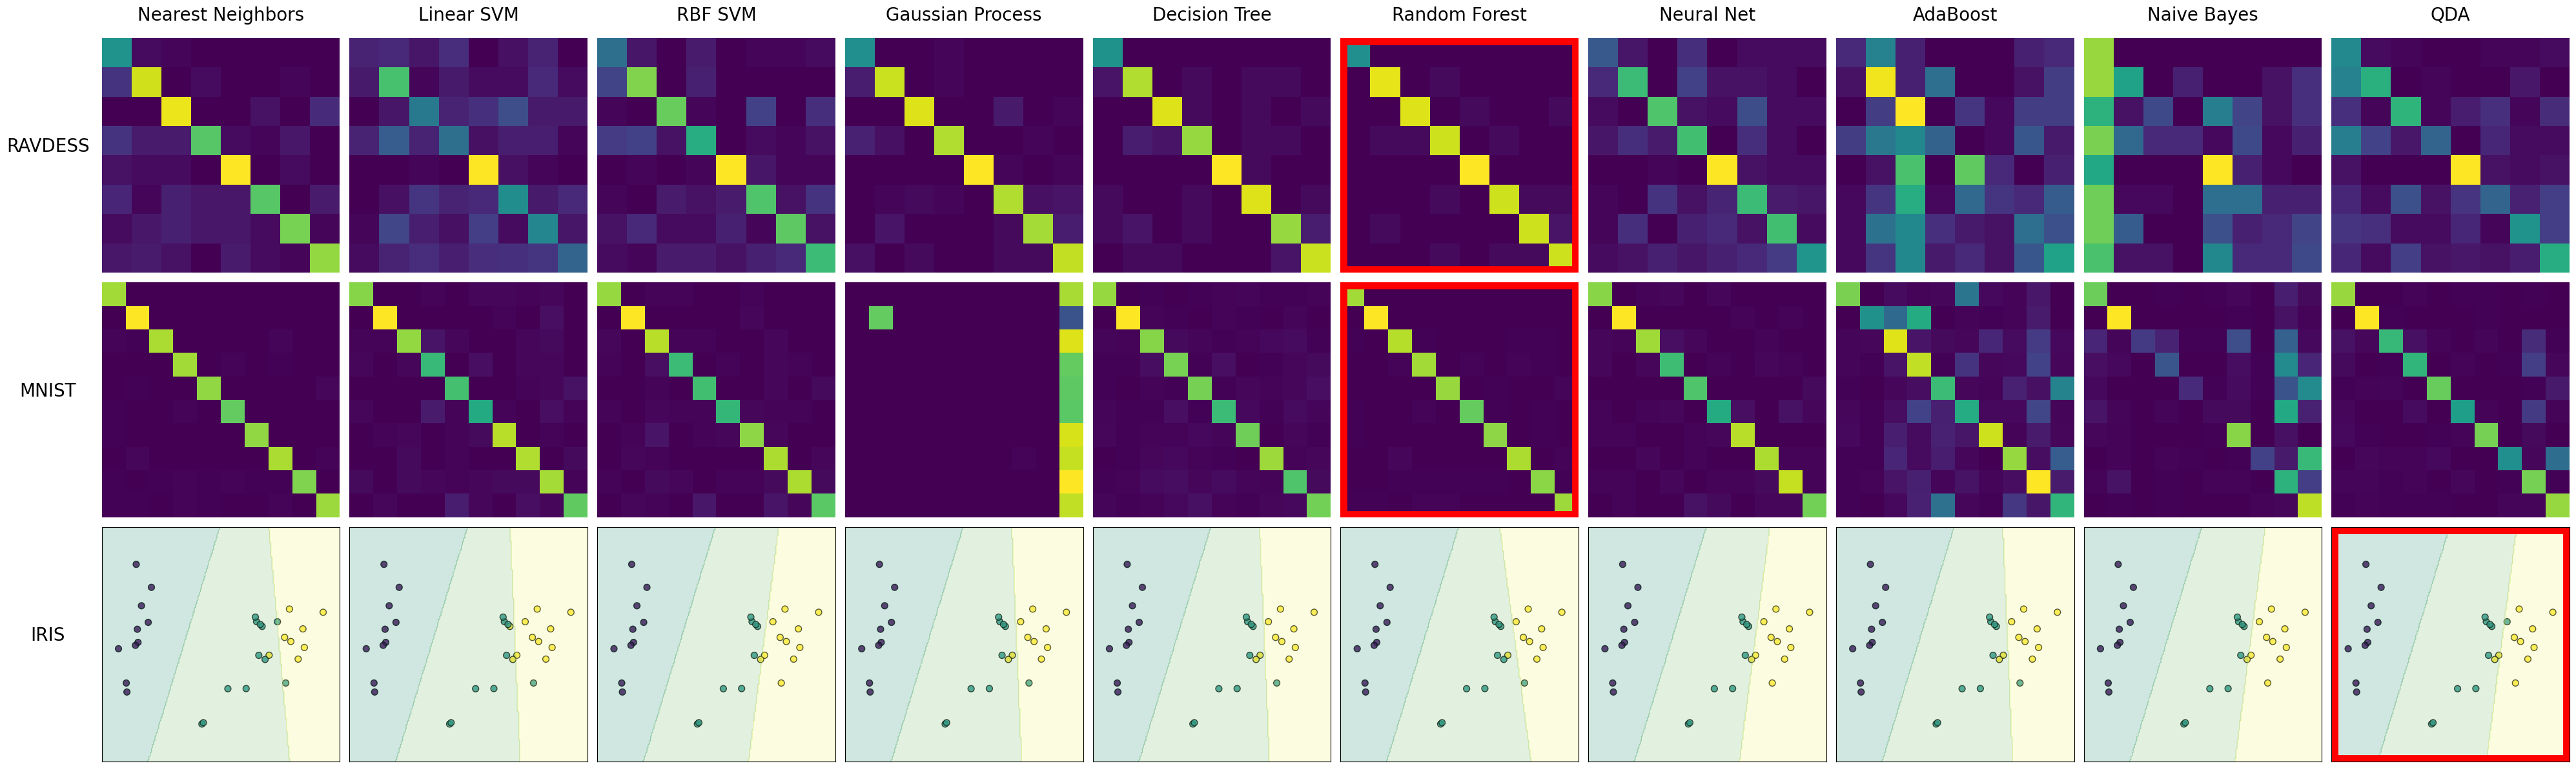

In [29]:
# Define best models
best_models = {
    "RAVDESS": "Random Forest",
    "MNIST": "Random Forest",
    "IRIS": "QDA"
}

datasets = {
    "RAVDESS": (X_test_ravdess, y_test_ravdess, predictions_ravdess),
    "MNIST": (x_test_mnist_flat, y_test_mnist, predictions_mnist),
    "IRIS": (X_test_iris, y_test_iris, predictions_iris)
}

n_models = len(predictions_ravdess) # each datasets  should have the same models

fig, axes = plt.subplots(nrows=len(datasets), ncols=n_models, figsize=(4*n_models, 12))
axes = np.atleast_2d(axes)

model_title_size = 20
dataset_label_size = 20

for row_idx, (ds_name, (X_test, y_test, preds_dict)) in enumerate(datasets.items()):
    for col_idx, model_name in enumerate(preds_dict.keys()):
        ax = axes[row_idx, col_idx]
        y_pred, y_true = preds_dict[model_name]

        # IRIS scatter + decision boundary
        if ds_name == "IRIS":
            X_2d = PCA(n_components=2).fit_transform(X_test) if X_test.shape[1] > 2 else X_test
            ax.scatter(X_2d[:,0], X_2d[:,1], c=y_pred, cmap='viridis', s=50, alpha=0.8, edgecolors='k')
            clf_2d = SVC(kernel='linear')
            clf_2d.fit(X_2d, y_pred)
            x_min, x_max = X_2d[:,0].min() - 0.5, X_2d[:,0].max() + 0.5
            y_min, y_max = X_2d[:,1].min() - 0.5, X_2d[:,1].max() + 0.5
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
            Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, alpha=0.2, cmap='summer')

        # MNIST & RAVDESS heatmap
        else:
            cm = confusion_matrix(y_true, y_pred)
            sns.heatmap(cm, annot=False, cmap='viridis', cbar=False, ax=ax)

        # Column title = model name
        if row_idx == 0:
            ax.set_title(model_name, fontsize=model_title_size, pad=20)
        # Row label = dataset name
        if col_idx == 0:
            ax.set_ylabel(ds_name, fontsize=dataset_label_size, rotation=0, labelpad=60)

        # Remove ticks
        ax.set_xticks([])
        ax.set_yticks([])

        # Add red border for the best model
        if model_name == best_models[ds_name]:
            # Rectangle covering the axes
            rect = patches.Rectangle(
                (0, 0), 1, 1, transform=ax.transAxes,
                linewidth=15, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

plt.tight_layout()
plt.show()


Test split index : 517
True emotion     : 0 (neutral)
Predicted emotion: 0 (neutral)
DataFrame index  : 1982
Filepath         : C:\Users\remic\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1\audio_speech_actors_01-24\Actor_10\03-01-01-01-02-01-10.wav



MNIST sample index: 37
True digit: 1, Predicted: 1


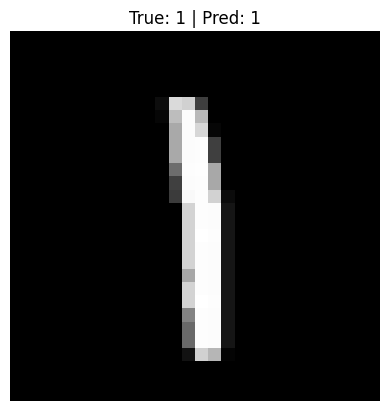


IRIS sample index: 22
Features: [6.6 2.9 4.6 1.3]
True class: 1 (versicolor), Predicted: 1 (versicolor)


In [30]:
# Random sample indices
idx_ravdess = random.randint(0, len(y_test_ravdess)-1)
idx_mnist = random.randint(0, len(y_test_mnist_small)-1)
idx_iris = random.randint(0, len(y_test_iris)-1)

# ---- RAVDESS ----
# Labels are 0–7model
emotion_map = {
    0: "neutral",
    1: "calm",
    2: "happy",
    3: "sad",
    4: "angry",
    5: "fearful",
    6: "disgust",
    7: "surprised"
}

# True & predicted label from TEST set
true_ravdess = y_test_ravdess[idx_ravdess]
pred_ravdess = predictions_ravdess["Random Forest"][0][idx_ravdess]

print(f"Test split index : {idx_ravdess}")
print(f"True emotion     : {true_ravdess} ({emotion_map[true_ravdess]})")
print(f"Predicted emotion: {pred_ravdess} ({emotion_map[pred_ravdess]})")

# Find the original dataframe row
df_idx = idx_test_ravdess[idx_ravdess]

# Get filepath from the dataframe
audio_file = df_ravdess.iloc[df_idx]["filepath"]
print(f"DataFrame index  : {df_idx}")
print(f"Filepath         : {audio_file}")

display(Audio(audio_file))

# ---- MNIST ----
true_mnist = y_test_mnist[idx_mnist]
pred_mnist = predictions_mnist["Random Forest"][0][idx_mnist]
print(f"\nMNIST sample index: {idx_mnist}")
print(f"True digit: {true_mnist}, Predicted: {pred_mnist}")

# Display image
plt.imshow(x_test_mnist_flat[idx_mnist].reshape(28,28), cmap='gray')
plt.title(f"True: {true_mnist} | Pred: {pred_mnist}")
plt.axis('off')
plt.show()

# ---- IRIS ----
iris_map = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}
true_iris = y_test_iris[idx_iris]
pred_iris = predictions_iris["QDA"][0][idx_iris]
print(f"\nIRIS sample index: {idx_iris}")
print(f"Features: {X_test_iris[idx_iris]}")
print(f"True class: {true_iris} ({iris_map[true_iris]}), Predicted: {pred_iris} ({iris_map[pred_iris]})")
